# 30 m Grid Floor + Transparent Cubes (empty.umap)

30 m グリッド床 + 透明箱（最大 10,000）+ Humanoid + SpotDog を Unreal にスポーンします。

ロジック本体は同ディレクトリの `grid_env_hri_simulation.py` です。この Notebook からはモジュールを import して段階実行します。

## 前提

1. **Windows**: `C:\SimWorldServer` で SimWorld を起動
   ```text
   .\SimWorld.exe -windowed -log /Game/Maps/empty.umap
   ```
2. **pakchunk9002** に `BP_Floor_30x30` / `BP_TransparentCube` が含まれていること
3. **WSL**: `conda activate simworld` のカーネルで実行

## 座標系（UE cm、empty マップ）

- 床 30 m 四方の **左下隅** が `(x, y) = (0, 0)`
- 床上面の高さ = **100 cm**（empty 原点から 1 m）
- Human / Robot のマップ座標 [m] は material_transport の grid_map と同じ比率（既定: human `(1,1)`, robot `(1,3)`）
- Humanoid / Robot は **床面上に直接配置**（Simulated Physics は既定 OFF。ON にするとラグドール化します）
- 透明箱は `SetBlocking` + 短い落下（`CUBE_SPAWN_ABOVE_FLOOR_CM` 既定 5 cm）で可視化

## 実行順

1. 初期設定 → 2. UE 接続 → 3. 設定（`GRID_N`）→ 4. 床 → 5. 箱 → 6. エージェント → 7. 落下待ち  
小規模テストは **設定** セルで `GRID_N = 3`（9 箱）にしてからスポーンしてください。

In [1]:
import importlib
import os
import socket
import subprocess
import sys
import time
from pathlib import Path
from typing import List, Optional, Tuple


def _find_project_root() -> Path:
    search_starts = []
    if "__file__" in globals():
        search_starts.append(Path(__file__).resolve().parent)
    search_starts.append(Path.cwd().resolve())

    for start in search_starts:
        for candidate in (start, *start.parents):
            if (candidate / "setup.py").exists() and (candidate / "simworld").is_dir():
                return candidate

    return Path.cwd().resolve().parent.parent


_root = _find_project_root()
_geh_dir = _root / "dev" / "grid_env_hri"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
if str(_geh_dir) not in sys.path:
    sys.path.insert(0, str(_geh_dir))

from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV

ucv: Optional[UnrealCV] = None
communicator: Optional[Communicator] = None
UE_PORT = 9000

print(f"[Paths] root={_root}")
print(f"[Paths] grid_env_hri={_geh_dir}")

[Paths] root=/home/winder17wsl_ishizawalab/00_kotaprivate/Program/SimWorld
[Paths] grid_env_hri=/home/winder17wsl_ishizawalab/00_kotaprivate/Program/SimWorld/dev/grid_env_hri


In [2]:
def _is_wsl() -> bool:
    version_path = Path("/proc/version")
    if not version_path.exists():
        return False
    text = version_path.read_text(encoding="utf-8").lower()
    return "microsoft" in text or "wsl" in text


def _wsl_default_gateway_ip() -> Optional[str]:
    try:
        result = subprocess.run(
            ["ip", "route", "show", "default"],
            capture_output=True,
            text=True,
            timeout=3,
            check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    parts = result.stdout.split()
    if len(parts) >= 3 and parts[0] == "default" and parts[1] == "via":
        return parts[2]
    return None


def _windows_host_ip_from_resolv() -> Optional[str]:
    resolv_path = Path("/etc/resolv.conf")
    if not resolv_path.exists():
        return None
    for line in resolv_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line.startswith("nameserver"):
            parts = line.split()
            if len(parts) >= 2:
                return parts[1]
    return None


def _ue_host_candidates() -> List[str]:
    hosts: List[str] = []
    if _is_wsl():
        for candidate in (_wsl_default_gateway_ip(), _windows_host_ip_from_resolv()):
            if candidate and candidate not in hosts:
                hosts.append(candidate)
        if "127.0.0.1" not in hosts:
            hosts.append("127.0.0.1")
        return hosts
    hosts.append("127.0.0.1")
    resolv_ip = _windows_host_ip_from_resolv()
    if resolv_ip and resolv_ip not in hosts:
        hosts.append(resolv_ip)
    return hosts


def _probe_unrealcv_endpoint(host: str, port: int = UE_PORT, timeout: float = 2.0) -> bool:
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(timeout)
    try:
        sock.connect((host, port))
        banner = sock.recv(64)
        return b"connected" in banner
    except OSError:
        return False
    finally:
        sock.close()


def ensure_connection() -> Tuple[UnrealCV, Communicator]:
    """UnrealCV / Communicator を初期化（WSL では Windows ホスト IP を自動探索）。"""
    global ucv, communicator

    if ucv is not None and ucv.client.isconnected():
        if communicator is None or communicator.unrealcv is not ucv:
            communicator = Communicator(ucv)
        return ucv, communicator

    if ucv is not None:
        try:
            ucv.disconnect()
        except Exception:
            pass
        ucv = None
        communicator = None

    errors: List[str] = []
    for host in _ue_host_candidates():
        if not _probe_unrealcv_endpoint(host, UE_PORT):
            errors.append(f"{host}:{UE_PORT} — not UnrealCV")
            continue
        try:
            ucv = UnrealCV(port=UE_PORT, ip=host)
            communicator = Communicator(ucv)
            print(f"[UE] Connected via UnrealCV at {host}:{UE_PORT}")
            return ucv, communicator
        except Exception as exc:
            errors.append(f"{host}:{UE_PORT} — {exc}")
            ucv = None
            communicator = None

    raise ConnectionError(
        "Unreal Engine (UnrealCV) に接続できませんでした。\n"
        "1. Windows で SimWorld を起動:\n"
        "     cd C:\\SimWorldServer\n"
        "     .\\SimWorld.exe -windowed -log /Game/Maps/empty.umap\n"
        "2. ログに `Start listening on port 9000` があるか確認\n"
        "3. Kernel → Restart 後、初期設定 → UE 接続の順で再実行\n"
        "試行結果:\n  - " + "\n  - ".join(errors)
    )

In [3]:
ucv, communicator = ensure_connection()

INFO:__init__:238:Got connection confirm: b'connected to SimWorld'


=>Info: using ip-port socket
[UE] Connected via UnrealCV at 127.0.0.1:9000


In [4]:
# ---- 実行パラメータ（Notebook 既定は小規模テスト） ----
GRID_N = 3  # 本番 10,000 箱: 100
SPAWN_INTERVAL_S = 0.005
CUBE_ENABLE_PHYSICS = True
CUBE_SPAWN_ABOVE_FLOOR_CM = 5.0  # 大きいと角の箱が床外へ弾ける
AGENT_ENABLE_PHYSICS = False  # True でも Humanoid/Robot では無視（ラグドール防止）

os.environ["GRID_N"] = str(GRID_N)
os.environ["SPAWN_INTERVAL_S"] = str(SPAWN_INTERVAL_S)
os.environ["CUBE_ENABLE_PHYSICS"] = "1" if CUBE_ENABLE_PHYSICS else "0"
os.environ["CUBE_SPAWN_ABOVE_FLOOR_CM"] = str(CUBE_SPAWN_ABOVE_FLOOR_CM)
os.environ["AGENT_ENABLE_PHYSICS"] = "1" if AGENT_ENABLE_PHYSICS else "0"

import grid_env_hri_simulation as geh

importlib.reload(geh)

cube_registry: dict = {}
human_name: Optional[str] = None
robot_ok: bool = False

print(
    f"[Config] GRID_N={geh.GRID_N} ({geh.GRID_N ** 2} cubes), "
    f"floor_top_z={geh.FLOOR_TOP_Z_CM} cm, origin={geh.MAP_ORIGIN_XY_CM}"
)
print(
    f"  human map={geh.HUMAN_MAP_XY_M} m, robot map={geh.ROBOT_MAP_XY_M} m, "
    f"cube_physics={geh.CUBE_ENABLE_PHYSICS}, cube_drop_cm={geh.CUBE_SPAWN_ABOVE_FLOOR_CM}, "
    f"human_z={geh.HUMAN_SPAWN_Z_CM}, robot_z={geh.ROBOT_SPAWN_Z_CM}"
)

[Config] GRID_N=3 (9 cubes), floor_top_z=100.0 cm, origin=(0.0, 0.0)
  human map=(1.0, 1.0) m, robot map=(1.0, 3.0) m, cube_physics=True, agent_physics=True


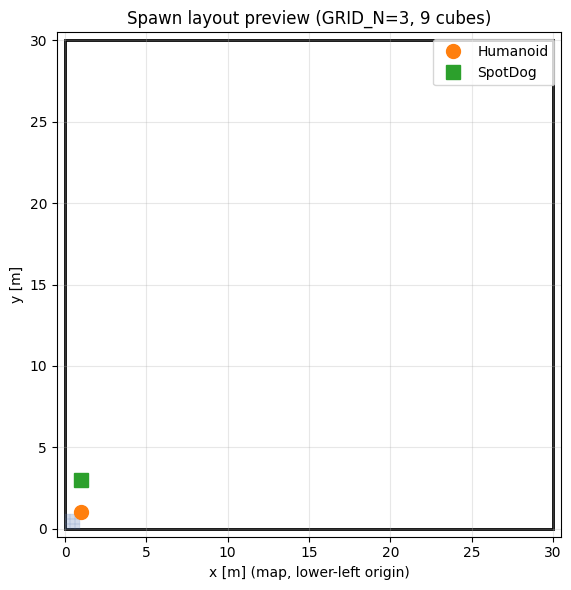

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))
floor_m = geh.FLOOR_SIZE_M
ax.add_patch(
    mpatches.Rectangle((0, 0), floor_m, floor_m, fill=False, edgecolor="black", linewidth=2)
)

n = geh.GRID_N
cube_m = geh.CUBE_SIZE_M
for row in range(n):
    for col in range(n):
        ax.add_patch(
            mpatches.Rectangle(
                (col * cube_m, row * cube_m),
                cube_m,
                cube_m,
                facecolor="#4c72b0",
                alpha=0.25,
                edgecolor="#4c72b0",
                linewidth=0.3,
            )
        )

hx, hy = geh.HUMAN_MAP_XY_M
rx, ry = geh.ROBOT_MAP_XY_M
ax.plot(hx, hy, "o", color="tab:orange", markersize=10, label="Humanoid")
ax.plot(rx, ry, "s", color="tab:green", markersize=10, label="SpotDog")

ax.set_xlim(-0.5, floor_m + 0.5)
ax.set_ylim(-0.5, floor_m + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("x [m] (map, lower-left origin)")
ax.set_ylabel("y [m]")
ax.set_title(f"Spawn layout preview (GRID_N={n}, {n * n} cubes)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
if not geh.spawn_fixed_floor(ucv):
    raise RuntimeError("[Floor] spawn failed — PAK / BP パス / SimWorld 再起動を確認")

[Floor] fixed at center=(1500.0, 1500.0, 100.0) (corner @ (0.0, 0.0), top Z≈100.0 cm)


In [7]:
cube_registry = geh.spawn_cubes(ucv, geh.GRID_N)
print(f"[Cubes] registry size: {len(cube_registry)}")

[Cubes] spawning 9 (GRID_N=3, physics=True)
  row 3/3 (9/9)
[Cubes] done: 9
[Cubes] registry size: 9


In [8]:
human_name = geh.spawn_humanoid(communicator, ucv)
robot_ok = geh.spawn_robot(ucv)
print(f"[Agents] humanoid={human_name}, robot_ok={robot_ok}")

(100.0, 100.0, 180.0)
[Humanoid] GEN_BP_Humanoid_0 spawn @ (100.0, 100.0, 180.0) physics=True
[Robot] GridEnv_SpotRobot @ (100.0, 300.0, 180.0) physics=True
[Agents] humanoid=GEN_BP_Humanoid_0, robot_ok=True


In [9]:
if geh.SETTLE_AFTER_SPAWN_S > 0:
    print(f"[Settle] waiting {geh.SETTLE_AFTER_SPAWN_S}s for physics ...")
    time.sleep(geh.SETTLE_AFTER_SPAWN_S)

geh.report_spawn_state(ucv, cube_registry, human_name)

print("[Done]")
print(f"  floor: {geh.FLOOR_ACTOR_NAME}")
print(f"  cubes: {len(cube_registry)}")
print(f"  humanoid: {human_name}")
print(f"  robot: {geh.ROBOT_ACTOR_NAME if robot_ok else 'FAILED'}")

[Settle] waiting 6.0s for physics ...
[Done]
  floor: grid_floor_main
  cubes: 9
  humanoid: GEN_BP_Humanoid_0
  robot: GridEnv_SpotRobot


## クリーンアップ（任意）

スポーンした床・箱・ロボットを Unreal から削除します。Humanoid は Communicator 経由のため、必要に応じて UE 側で手動削除してください。

In [11]:
# RUN_CLEANUP = True にしてから実行
RUN_CLEANUP = False

if RUN_CLEANUP:
    geh.cleanup_spawned(ucv, cube_registry.keys())
    print("[Cleanup] floor, cubes, robot destroyed.")
else:
    print("[Cleanup] skipped (set RUN_CLEANUP = True to destroy spawned actors)")

[Cleanup] skipped (set RUN_CLEANUP = True to destroy spawned actors)
